 <div align="center">

#  AI Student Impact Analytics
### Evaluating the Influence of Generative AI on Academic Performance

</div>

---

###  Problem Statement

The increasing adoption of Generative AI tools has transformed the way students learn, complete assignments, and prepare for examinations. This project analyzes the impact of AI usage on academic performance, learning outcomes, dependency levels, and student well-being.

### Objectives

* Analyze the relationship between AI usage and academic performance.
* Measure GPA changes before and after AI adoption.
* Evaluate the impact of AI dependency on skill retention.
* Examine how AI influences traditional study habits.
* Analyze the relationship between AI usage, anxiety levels, and burnout risk.
* Assess the influence of prompt engineering skills on academic outcomes.

---


Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

In [11]:
df = pd.read_csv(r"C:\Users\user\Downloads\ai_student_impact_dataset (1).csv")
print(df.head(5))

   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  \
0               1               True                     8.13   
1               5     

Data Understanding

In [12]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [13]:
df.shape

(50000, 16)

In [14]:
df.dtypes

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


Feature Engineering

In [17]:
df["GPA_Improvement"] = (
    df["Post_Semester_GPA"]
    - df["Pre_Semester_GPA"]
)

In [18]:
print(df["GPA_Improvement"])

0       -0.025
1       -0.125
2        0.101
3        0.211
4        0.163
         ...  
49995    0.685
49996    0.226
49997    0.428
49998    0.129
49999    0.019
Name: GPA_Improvement, Length: 50000, dtype: float64


In [19]:
df["GPA_Improvement"].describe()

count    50000.000000
mean         0.203197
std          0.187192
min         -0.924000
25%          0.087000
50%          0.204000
75%          0.325000
max          1.008000
Name: GPA_Improvement, dtype: float64

In [20]:
df["AI_Usage_Group"] = pd.cut(
    df["Weekly_GenAI_Hours"],
    bins=[0, 5, 10, 20, 100],
    labels=["Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

In [21]:
df["AI_Usage_Group"].isna().sum()

np.int64(0)

In [34]:
df.to_csv("student_ai_analysis.csv", index=False)

1 How has student academic performance changed after the adoption of Generative AI tools?

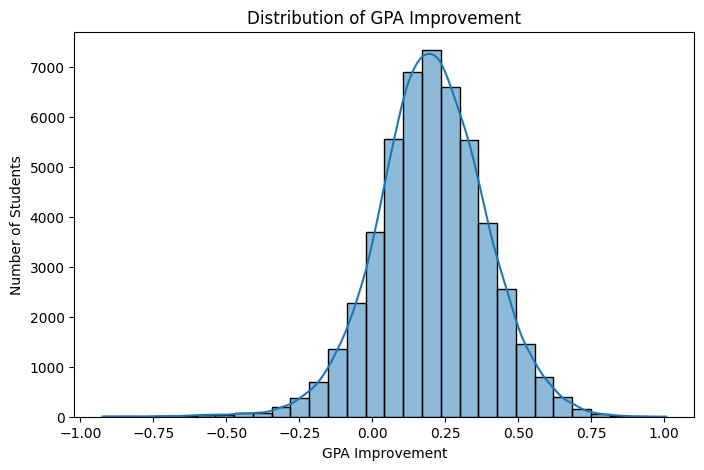

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["GPA_Improvement"], bins=30, kde=True)

plt.title("Distribution of GPA Improvement")
plt.xlabel("GPA Improvement")
plt.ylabel("Number of Students")

plt.show()



- The distribution of GPA improvement follows an approximately normal pattern centered around a positive value.
- The average GPA improvement was approximately 0.20 points, indicating that most students experienced better academic performance after the semester.
- The majority of students showed positive GPA growth, while only a small proportion experienced a decline in performance.
- Overall, the results suggest a positive academic trend among students during the study period.

2 Is there a noticeable difference between students' pre-semester and post-semester GPA?

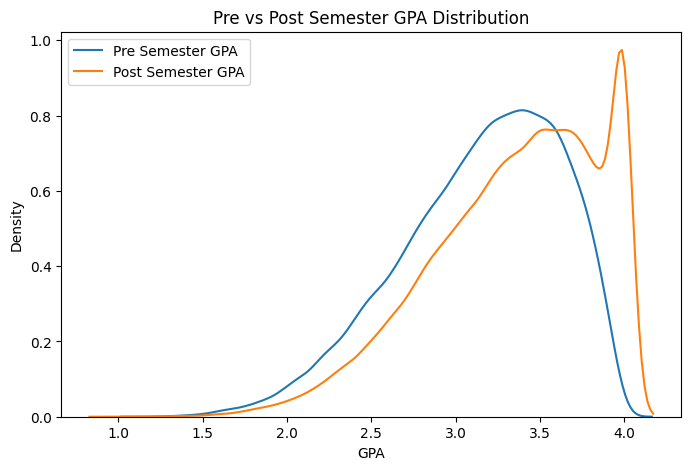

In [24]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["Pre_Semester_GPA"], label="Pre Semester GPA")
sns.kdeplot(df["Post_Semester_GPA"], label="Post Semester GPA")

plt.title("Pre vs Post Semester GPA Distribution")
plt.xlabel("GPA")
plt.legend()

plt.show()

Students generally achieved higher GPAs after incorporating Generative AI tools into their learning process, suggesting a positive impact of AI-assisted studying on academic achievement.

3 Does higher AI usage lead to greater GPA improvement?

<Axes: xlabel='Weekly_GenAI_Hours', ylabel='GPA_Improvement'>

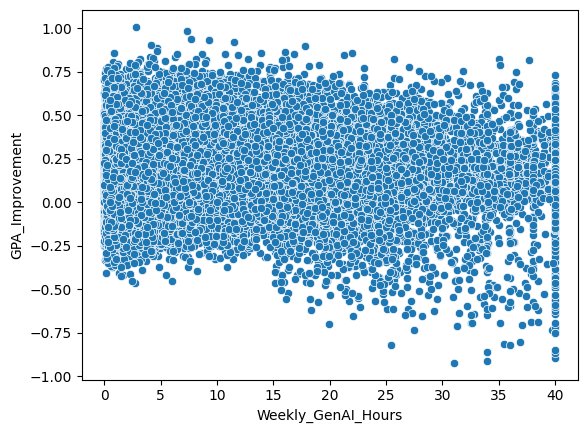

In [25]:
sns.scatterplot(
    data=df,
    x='Weekly_GenAI_Hours',
    y='GPA_Improvement'
)

In [26]:
df['Weekly_GenAI_Hours'].corr(df['GPA_Improvement'])

np.float64(-0.046479283140597336)

The scatter plot shows no clear relationship between Weekly Generative AI Hours and GPA Improvement. The correlation coefficient (-0.046) indicates an extremely weak negative correlation.

Higher AI usage does not necessarily lead to greater GPA improvement. Academic performance appears to depend more on the quality and effectiveness of AI usage rather than the amount of time spent using AI tools.

4 How does Generative AI usage affect traditional study habits?

np.float64(-0.15736782795222679)

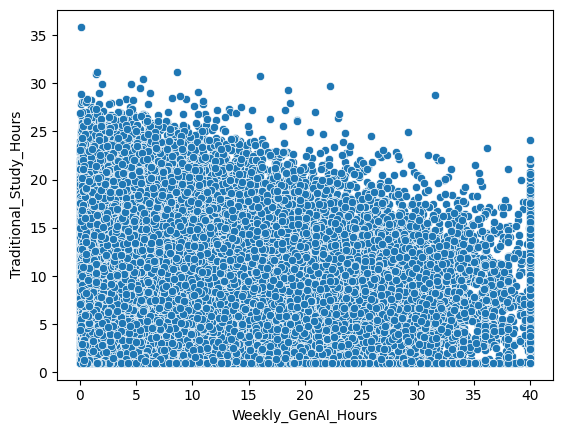

In [27]:
sns.scatterplot(
    data=df,
    x='Weekly_GenAI_Hours',
    y='Traditional_Study_Hours'
)

df['Weekly_GenAI_Hours'].corr(df['Traditional_Study_Hours'])

The scatter plot shows a weak negative relationship between Weekly Generative AI Hours and Traditional Study Hours. The correlation coefficient (-0.157) suggests that students who spend more time using AI tend to spend slightly less time on traditional study methods.

 5 Does AI dependency impact skill retention?

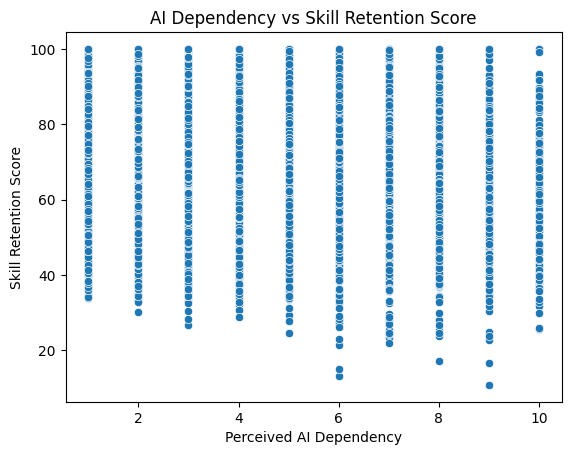

np.float64(-0.08432431881589098)

In [28]:
sns.scatterplot(
    data=df,
    x='Perceived_AI_Dependency',
    y='Skill_Retention_Score'
)

plt.title('AI Dependency vs Skill Retention Score')
plt.xlabel('Perceived AI Dependency')
plt.ylabel('Skill Retention Score')

plt.show()

df['Perceived_AI_Dependency'].corr(df['Skill_Retention_Score'])

The scatter plot shows no strong relationship between AI dependency and skill retention. Students with different dependency levels have a wide range of skill retention scores

Higher AI dependency does not significantly reduce skill retention. The impact of AI on learning retention may depend more on how students use AI rather than their dependency level alone.

6 Does prompt engineering skill influence academic outcomes?

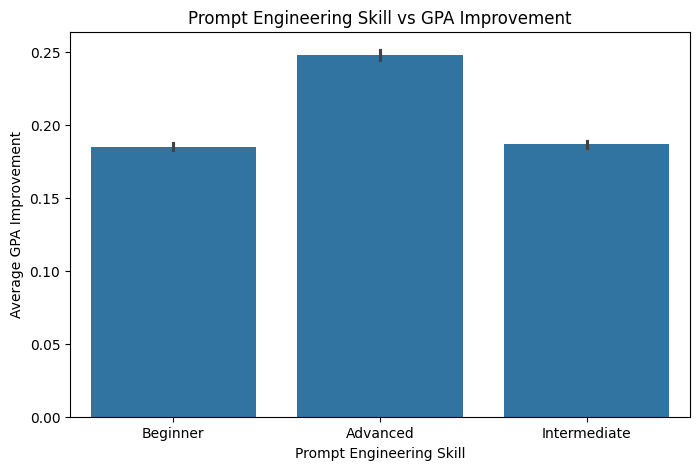

In [29]:
df.groupby('Prompt_Engineering_Skill')['GPA_Improvement'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Prompt_Engineering_Skill',
    y='GPA_Improvement'
)

plt.title('Prompt Engineering Skill vs GPA Improvement')
plt.xlabel('Prompt Engineering Skill')
plt.ylabel('Average GPA Improvement')

plt.show()

Students with advanced prompt engineering skills show the highest average GPA improvement compared to intermediate and beginner users.

Better prompt engineering skills may help students use AI tools more effectively, leading to improved academic outcomes.

7 How does AI usage affect student well-being?

C:\Users\user\AppData\Local\Temp\ipykernel_17688\2406602893.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AI_Usage_Group')['Anxiety_Level_During_Exams'].mean()


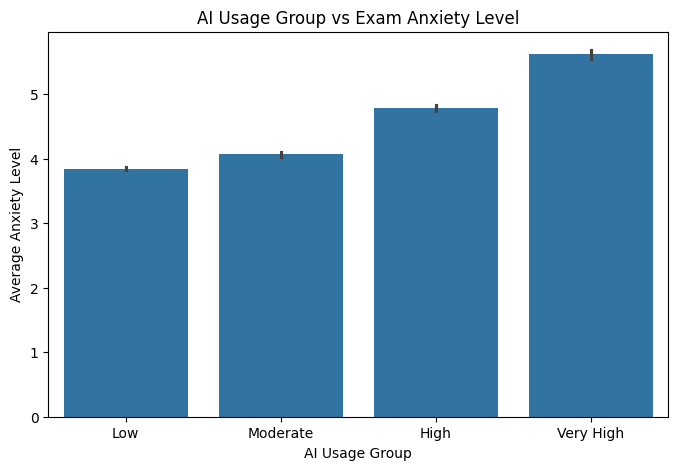

In [30]:
df.groupby('AI_Usage_Group')['Anxiety_Level_During_Exams'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='AI_Usage_Group',
    y='Anxiety_Level_During_Exams'
)

plt.title('AI Usage Group vs Exam Anxiety Level')
plt.xlabel('AI Usage Group')
plt.ylabel('Average Anxiety Level')

plt.show()

The chart shows that average anxiety levels increase as AI usage increases. Students in the Very High AI Usage group have the highest anxiety levels compared to Low and Moderate usage groups.

Higher AI usage is associated with increased exam anxiety, suggesting that excessive reliance on AI tools may contribute to additional academic pressure or stress.

8 Does AI usage influence burnout risk?

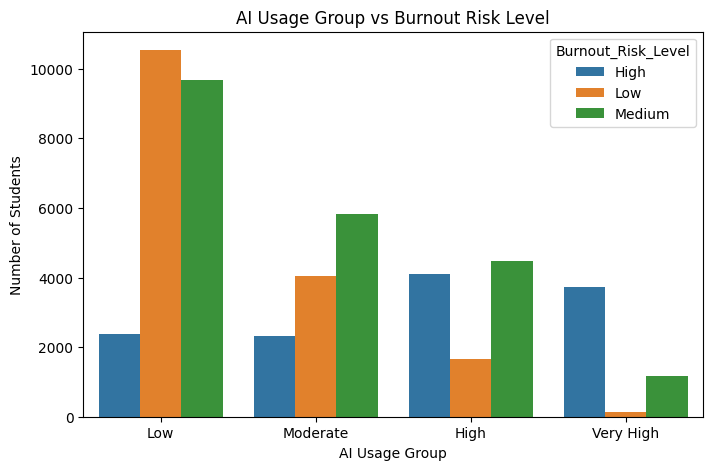

In [31]:
pd.crosstab(
    df['AI_Usage_Group'],
    df['Burnout_Risk_Level']
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='AI_Usage_Group',
    hue='Burnout_Risk_Level'
)

plt.title('AI Usage Group vs Burnout Risk Level')
plt.xlabel('AI Usage Group')
plt.ylabel('Number of Students')

plt.show()

Higher AI usage groups show a greater proportion of students with High burnout risk, while Low AI usage groups contain more students with Low and Medium burnout risk.

Excessive AI usage may be associated with increased burnout risk, suggesting that heavy reliance on AI tools could contribute to academic stress and pressure.

9 Which academic fields benefit most from Generative AI?

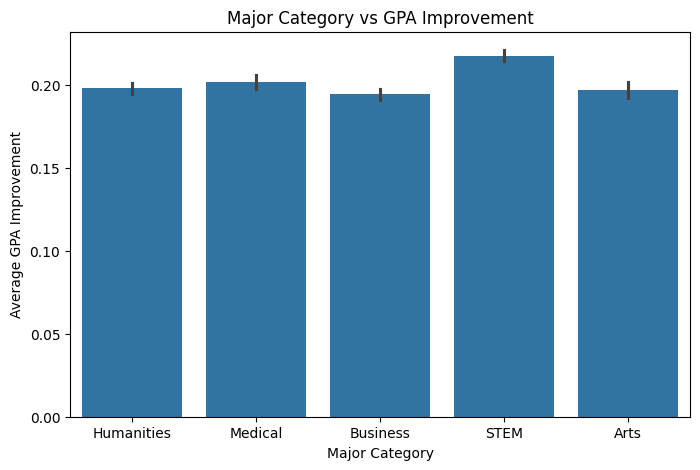

In [32]:
df.groupby('Major_Category')['GPA_Improvement'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Major_Category',
    y='GPA_Improvement'
)

plt.title('Major Category vs GPA Improvement')
plt.xlabel('Major Category')
plt.ylabel('Average GPA Improvement')

plt.show()

The chart shows that all major categories experienced positive GPA improvement after AI adoption. STEM students show the highest average GPA improvement, while Business, Humanities, and Arts show slightly lower improvements.

Generative AI appears to benefit students across all academic fields, with STEM students showing the strongest improvement, possibly due to greater use of AI for technical problem-solving and learning support.

10  What factors are most related to GPA improvement?

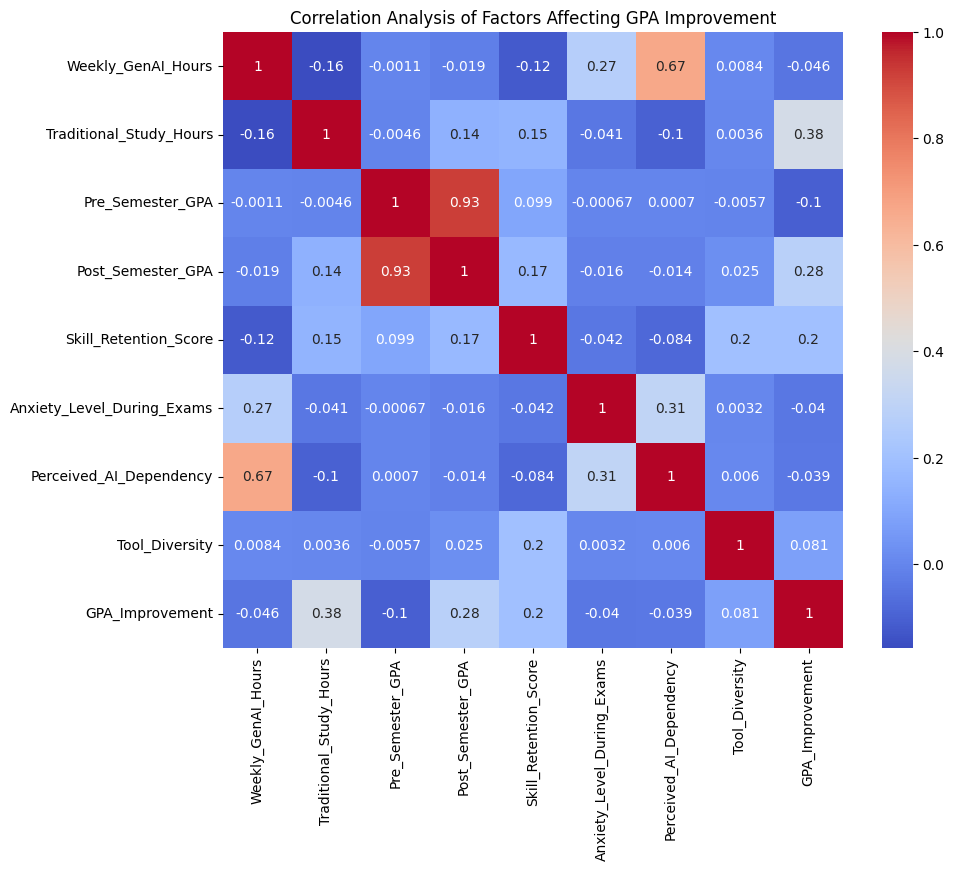

In [33]:
corr_cols = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Skill_Retention_Score',
    'Anxiety_Level_During_Exams',
    'Perceived_AI_Dependency',
    'Tool_Diversity',
    'GPA_Improvement'
]

df[corr_cols].corr()['GPA_Improvement'].sort_values(ascending=False)

plt.figure(figsize=(10,8))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Analysis of Factors Affecting GPA Improvement')

plt.show()

The correlation analysis shows that Traditional Study Hours has the strongest positive relationship with GPA Improvement (correlation ≈ 0.38), followed by Post Semester GPA (≈ 0.28) and Skill Retention Score (≈ 0.20). Weekly AI usage hours and AI dependency show very weak relationships with GPA improvement.

Academic improvement is influenced more by effective study habits and learning outcomes than by the amount of AI usage alone. AI tools appear to support learning, but they are not the only factor driving better academic performance.

EDA Final Conclusion

Exploratory analysis shows that Generative AI adoption is associated with positive academic outcomes, with most students experiencing GPA improvement after AI usage. However, the amount of AI usage alone does not strongly predict performance improvement. Factors such as traditional study habits, skill retention, and effective AI interaction skills play a more important role in determining student success.